## PROJECT 3: Returns Analysis & Product Quality Intelligence
Flipkart Dataset | Python End-to-End Pipeline
Business Problem:
  8% return rate eats into margin. Identify which
  products, categories, states, and order attributes
  drive returns — and build an actionable quality score.
=======================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ═══════════════════════════════════════════════════════
# 0. LOAD DATA
# ═══════════════════════════════════════════════════════
FILE = "Flipcart.xlsx"

customers    = pd.read_excel(FILE, sheet_name="customers",     parse_dates=["JoinDate"])
orders       = pd.read_excel(FILE, sheet_name="orders",        parse_dates=["OrderDate"])
order_details= pd.read_excel(FILE, sheet_name="order_details")
products     = pd.read_excel(FILE, sheet_name="products")
returns      = pd.read_excel(FILE, sheet_name="returns")

print("✅ Data loaded")
print(f"   Returns: {len(returns):,} out of {len(orders):,} orders "
      f"({len(returns)/len(orders)*100:.1f}% return rate)")

✅ Data loaded
   Returns: 240 out of 3,000 orders (8.0% return rate)


In [ ]:
# ═══════════════════════════════════════════════════════
# 1. BUILD MASTER RETURNS TABLE
# ═══════════════════════════════════════════════════════
returns_master = (
    returns
    .merge(orders[["OrderID","CustomerID","OrderDate","PaymentMethod"]], on="OrderID", how="left")
    .merge(order_details[["OrderID","ProductID","Quantity","UnitPrice"]], on="OrderID", how="left")
    .merge(products[["ProductID","ProductName","Category","Cost"]], on="ProductID", how="left")
    .merge(customers[["CustomerID","State"]], on="CustomerID", how="left")
)
returns_master["ReturnRevenue"] = returns_master["Quantity"] * returns_master["UnitPrice"]

# flag all orders with return status
orders_full = (
    orders
    .merge(order_details[["OrderID","ProductID","Quantity","UnitPrice"]], on="OrderID", how="left")
    .merge(products[["ProductID","Category","Cost"]], on="ProductID", how="left")
    .merge(customers[["CustomerID","State"]], on="CustomerID", how="left")
)
orders_full["Returned"] = orders_full["OrderID"].isin(returns["OrderID"]).astype(int)
orders_full["Revenue"]  = orders_full["Quantity"] * orders_full["UnitPrice"]

print(f"\n✅ Master returns table: {len(returns_master):,} rows")


✅ Master returns table: 240 rows


In [ ]:
# ═══════════════════════════════════════════════════════
# 2. RETURN RATE BY CATEGORY
# ═══════════════════════════════════════════════════════
cat_orders  = orders_full.groupby("Category")["OrderID"].count().rename("TotalOrders")
cat_returns = returns_master.groupby("Category")["ReturnID"].count().rename("ReturnCount")
cat_revenue_lost = returns_master.groupby("Category")["ReturnRevenue"].sum().rename("RevenueLost")

cat_analysis = pd.concat([cat_orders, cat_returns, cat_revenue_lost], axis=1).fillna(0).reset_index()
cat_analysis["ReturnRate%"] = (cat_analysis["ReturnCount"] / cat_analysis["TotalOrders"] * 100).round(2)
cat_analysis = cat_analysis.sort_values("ReturnRate%", ascending=False)

print("\n✅ Return Rate by Category:")
print(cat_analysis[["Category","TotalOrders","ReturnCount","ReturnRate%","RevenueLost"]].to_string(index=False))


✅ Return Rate by Category:
   Category  TotalOrders  ReturnCount  ReturnRate%  RevenueLost
    Fashion          464           46         9.91      1971163
Electronics          286           26         9.09       891062
     Sports          344           29         8.43      1198665
    Grocery          443           37         8.35      1221330
       Home          472           37         7.84      1429779
      Books          555           38         6.85      1621965
    Mobiles          436           27         6.19       975953


In [ ]:
# ═══════════════════════════════════════════════════════
# 3. RETURN REASON DISTRIBUTION BY CATEGORY
# ═══════════════════════════════════════════════════════
reason_cat = (
    returns_master
    .groupby(["Category","Reason"])["ReturnID"]
    .count()
    .unstack(fill_value=0)
)

# normalise to %
reason_cat_pct = reason_cat.div(reason_cat.sum(axis=1), axis=0) * 100

print("\n✅ Return Reason % by Category:")
print(reason_cat_pct.round(1).to_string())


✅ Return Reason % by Category:
Reason       Damaged  Not as Described  Size Issue  Wrong Product
Category                                                         
Books           18.4              23.7        21.1           36.8
Electronics     19.2              15.4        30.8           34.6
Fashion         17.4              32.6        28.3           21.7
Grocery         24.3              32.4        13.5           29.7
Home            21.6              27.0        24.3           27.0
Mobiles         25.9              33.3        22.2           18.5
Sports          17.2              31.0        17.2           34.5


In [ ]:
# ═══════════════════════════════════════════════════════
# 4. PRODUCT QUALITY SCORE
# ═══════════════════════════════════════════════════════
prod_orders  = orders_full.groupby("ProductID")["OrderID"].count().rename("TotalOrders")
prod_returns = returns_master.groupby("ProductID")["ReturnID"].count().rename("ReturnCount")
prod_revenue = returns_master.groupby("ProductID")["ReturnRevenue"].sum().rename("RevenueLost")

prod_quality = (
    pd.concat([prod_orders, prod_returns, prod_revenue], axis=1)
    .fillna(0)
    .reset_index()
    .merge(products[["ProductID","ProductName","Category","Cost"]], on="ProductID", how="left")
)
prod_quality["ReturnRate%"] = (prod_quality["ReturnCount"] / prod_quality["TotalOrders"].replace(0,np.nan) * 100).round(2)
# Quality score: 100 minus return rate, penalised if high damage/wrong-product
prod_quality["QualityScore"] = (100 - prod_quality["ReturnRate%"]).clip(lower=0)

# Flag high-risk products
prod_quality["HighRisk"] = prod_quality["ReturnRate%"] >= 15

high_risk_count = prod_quality["HighRisk"].sum()
print(f"\n✅ High-Risk Products (≥15% return rate): {high_risk_count}")
if high_risk_count > 0:
    print(prod_quality[prod_quality["HighRisk"]][["ProductName","Category","ReturnRate%","QualityScore"]].to_string(index=False))


✅ High-Risk Products (≥15% return rate): 35
      ProductName    Category  ReturnRate%  QualityScore
        Suscipit         Home        25.00         75.00
       Nulla Plus     Mobiles        15.38         84.62
 Perspiciatis Pro     Grocery        16.67         83.33
        Sequi Pro        Home        21.43         78.57
          Maxime         Home        16.67         83.33
          Nam Max      Sports        15.38         84.62
       Iure Ultra     Fashion        20.00         80.00
        Velit Pro     Fashion        25.00         75.00
       Alias Plus     Mobiles        20.00         80.00
     Repellat Max        Home        16.67         83.33
           Neque      Mobiles        15.79         84.21
    Accusamus Max     Fashion        17.39         82.61
       Ipsum Plus     Mobiles        15.00         85.00
         Iste Pro Electronics        20.00         80.00
          Aut Max     Fashion        18.75         81.25
        Ipsum Max     Grocery        15.00 

In [ ]:
# ═══════════════════════════════════════════════════════
# 5. RETURN RATE BY STATE
# ═══════════════════════════════════════════════════════
state_orders  = orders_full.groupby("State")["OrderID"].count().rename("TotalOrders")
state_returns = returns_master.groupby("State")["ReturnID"].count().rename("ReturnCount")

state_analysis = pd.concat([state_orders, state_returns], axis=1).fillna(0).reset_index()
state_analysis["ReturnRate%"] = (state_analysis["ReturnCount"] / state_analysis["TotalOrders"] * 100).round(2)
state_analysis = state_analysis.sort_values("ReturnRate%", ascending=False)

print("\n✅ Return Rate by State (top 5):")
print(state_analysis.head(5)[["State","TotalOrders","ReturnCount","ReturnRate%"]].to_string(index=False))


✅ Return Rate by State (top 5):
    State  TotalOrders  ReturnCount  ReturnRate%
      Goa           76         11.0        14.47
  Mizoram          152         20.0        13.16
Meghalaya           87         11.0        12.64
Jharkhand           66          8.0        12.12
   Kerala          107         12.0        11.21


In [ ]:
# ═══════════════════════════════════════════════════════
# 6. STATISTICAL TEST — unit price vs return rate
# ═══════════════════════════════════════════════════════
returned_prices = orders_full.loc[orders_full["Returned"]==1, "UnitPrice"].dropna()
normal_prices   = orders_full.loc[orders_full["Returned"]==0, "UnitPrice"].dropna()
t_stat, p_val   = stats.ttest_ind(returned_prices, normal_prices)

print(f"\n✅ T-test: returned avg ₹{returned_prices.mean():,.0f} vs "
      f"normal avg ₹{normal_prices.mean():,.0f}  | p={p_val:.4f} "
      f"{'→ SIGNIFICANT' if p_val < 0.05 else '→ not significant'}")


✅ T-test: returned avg ₹15,217 vs normal avg ₹14,992  | p=0.6970 → not significant


In [ ]:
# ═══════════════════════════════════════════════════════
# 7. MONTHLY RETURN TREND
# ═══════════════════════════════════════════════════════
returns_master["ReturnMonth"] = returns_master["OrderDate"].dt.to_period("M")
monthly_returns = (
    returns_master
    .groupby("ReturnMonth")
    .agg(ReturnCount=("ReturnID","count"), RevenueLost=("ReturnRevenue","sum"))
    .reset_index()
)
monthly_returns["ReturnMonth_str"] = monthly_returns["ReturnMonth"].astype(str)

In [ ]:
# ═══════════════════════════════════════════════════════
# 8. PAYMENT METHOD RETURN ANALYSIS
# ═══════════════════════════════════════════════════════
pay_orders  = orders_full.groupby("PaymentMethod")["OrderID"].count().rename("TotalOrders")
pay_returns = returns_master.groupby("PaymentMethod")["ReturnID"].count().rename("ReturnCount")
pay_analysis = pd.concat([pay_orders, pay_returns], axis=1).fillna(0).reset_index()
pay_analysis["ReturnRate%"] = (pay_analysis["ReturnCount"] / pay_analysis["TotalOrders"] * 100).round(2)

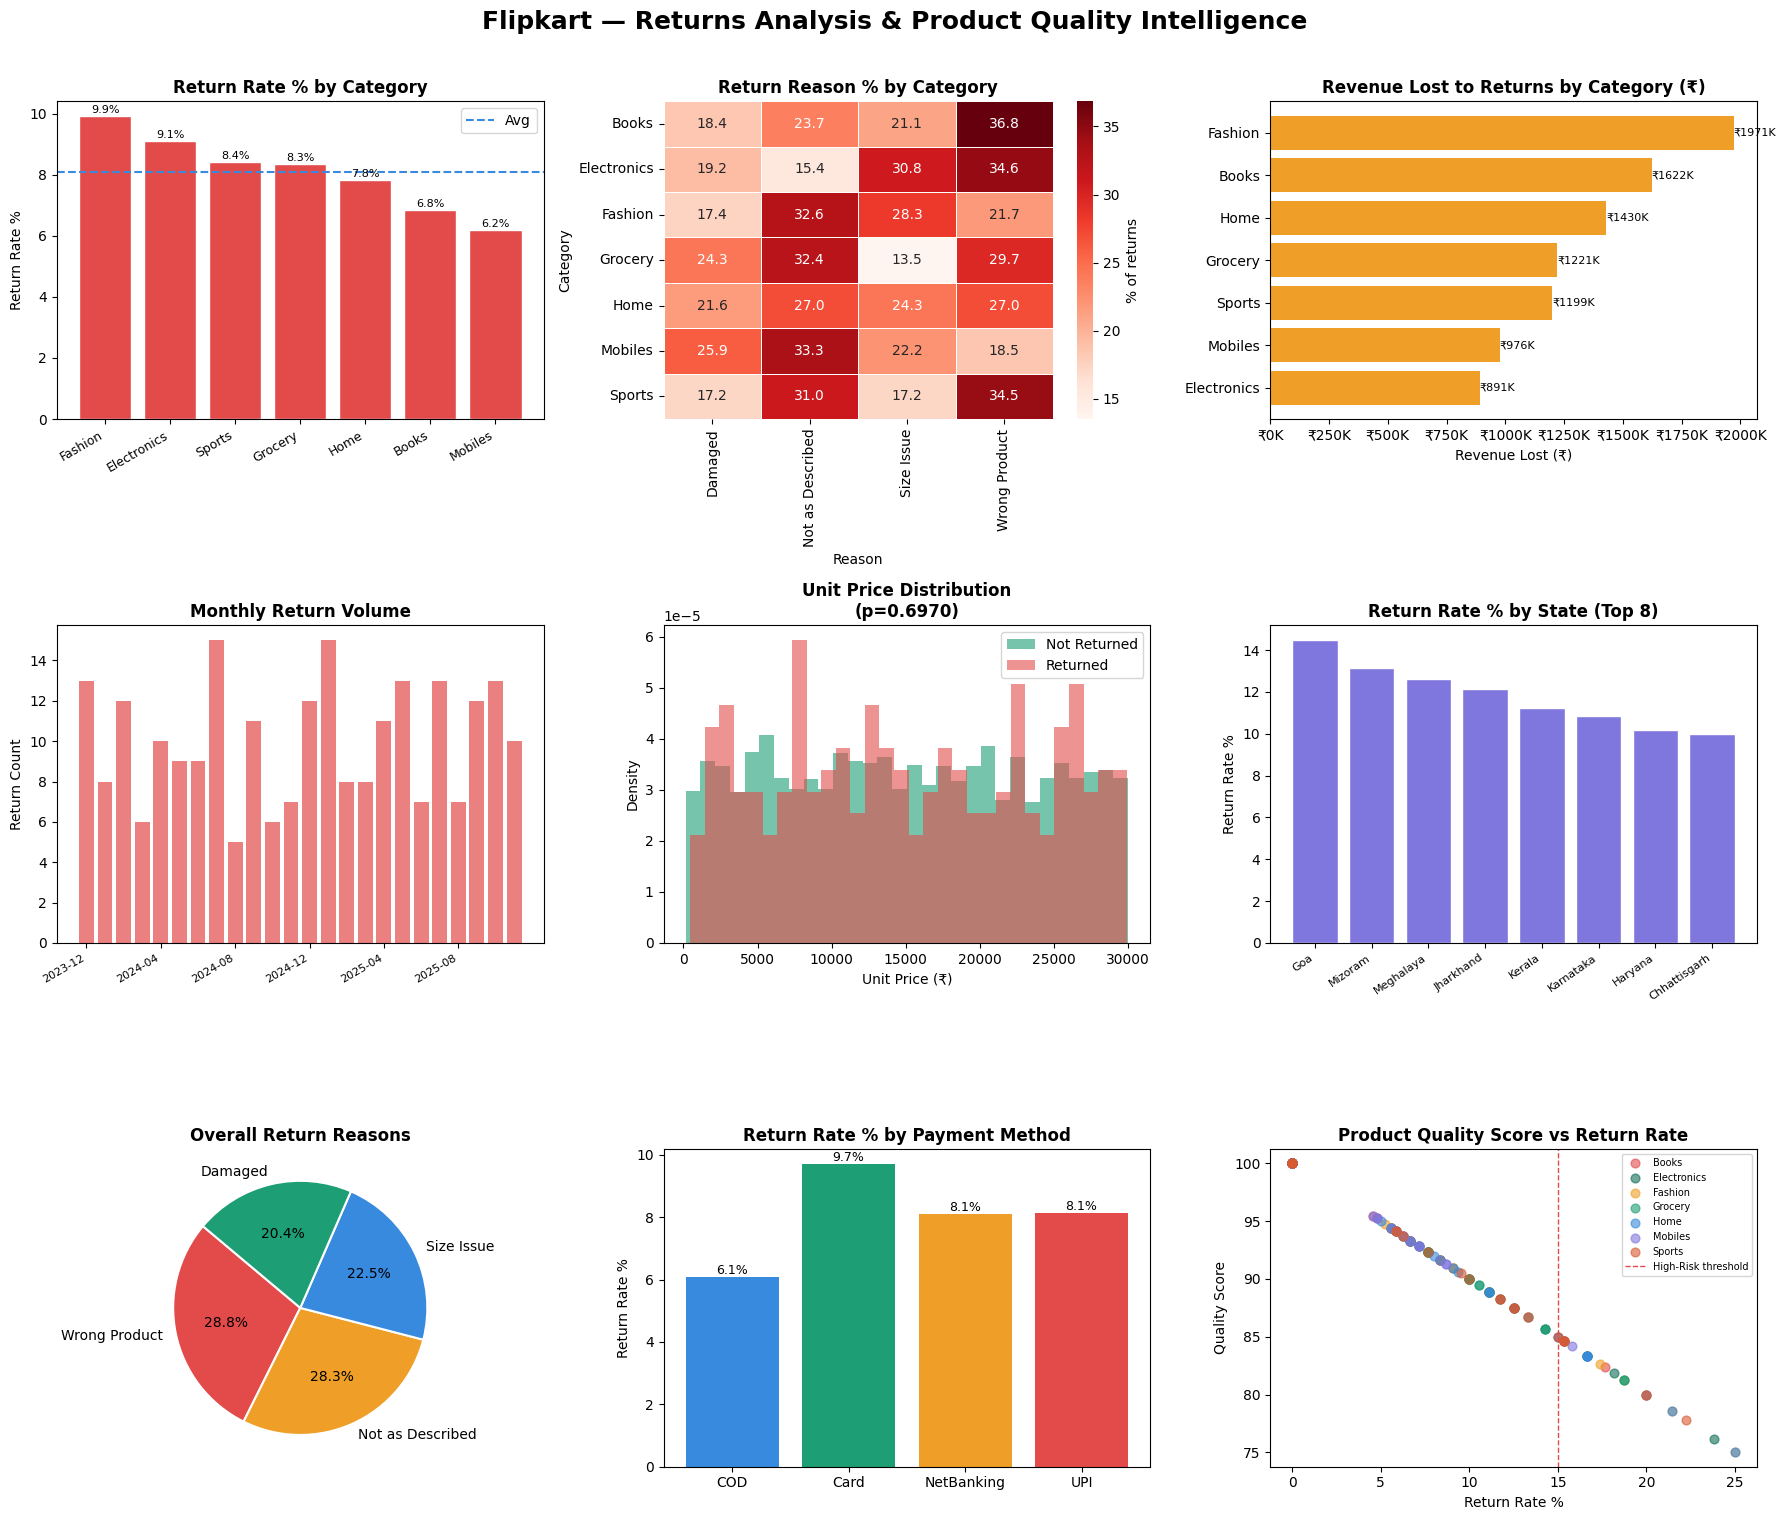

✅ Chart saved: project3_returns_analysis.png


In [ ]:
# ═══════════════════════════════════════════════════════
# 9. VISUALISATIONS
# ═══════════════════════════════════════════════════════
PALETTE = ["#E24B4A","#EF9F27","#378ADD","#1D9E75"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Flipkart — Returns Analysis & Product Quality Intelligence",
             fontsize=18, fontweight="bold", y=1.01)

# ── 1. Return rate by category ────────────────────────
ax = axes[0, 0]
bars = ax.bar(cat_analysis["Category"], cat_analysis["ReturnRate%"],
              color="#E24B4A", edgecolor="white")
ax.set_title("Return Rate % by Category", fontweight="bold")
ax.set_ylabel("Return Rate %")
ax.set_xticklabels(cat_analysis["Category"], rotation=30, ha="right", fontsize=9)
ax.axhline(cat_analysis["ReturnRate%"].mean(), ls="--", color="#378ADD", lw=1.5, label="Avg")
ax.legend()
for bar, val in zip(bars, cat_analysis["ReturnRate%"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{val:.1f}%", ha="center", fontsize=8)

# ── 2. Return reason heatmap ──────────────────────────
ax = axes[0, 1]
sns.heatmap(reason_cat_pct, annot=True, fmt=".1f", cmap="Reds",
            ax=ax, linewidths=0.5, cbar_kws={"label":"% of returns"})
ax.set_title("Return Reason % by Category", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ── 3. Revenue lost by category ───────────────────────
ax = axes[0, 2]
cat_rev_sorted = cat_analysis.sort_values("RevenueLost", ascending=True)
bars = ax.barh(cat_rev_sorted["Category"], cat_rev_sorted["RevenueLost"],
               color="#EF9F27")
ax.set_title("Revenue Lost to Returns by Category (₹)", fontweight="bold")
ax.set_xlabel("Revenue Lost (₹)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}K"))
for bar, val in zip(bars, cat_rev_sorted["RevenueLost"]):
    ax.text(val + 200, bar.get_y()+bar.get_height()/2,
            f"₹{val/1000:.0f}K", va="center", fontsize=8)

# ── 4. Monthly return trend ───────────────────────────
ax = axes[1, 0]
x = range(len(monthly_returns))
ax.bar(x, monthly_returns["ReturnCount"], color="#E24B4A", alpha=0.7, label="Returns")
step = max(1, len(monthly_returns)//6)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(monthly_returns["ReturnMonth_str"].iloc[::step], rotation=30, ha="right", fontsize=8)
ax.set_title("Monthly Return Volume", fontweight="bold")
ax.set_ylabel("Return Count")

# ── 5. Price distribution: returned vs not ───────────
ax = axes[1, 1]
ax.hist(normal_prices.clip(upper=30000), bins=30, alpha=0.6,
        color="#1D9E75", label="Not Returned", density=True)
ax.hist(returned_prices.clip(upper=30000), bins=30, alpha=0.6,
        color="#E24B4A", label="Returned", density=True)
ax.set_title(f"Unit Price Distribution\n(p={p_val:.4f})", fontweight="bold")
ax.set_xlabel("Unit Price (₹)"); ax.set_ylabel("Density")
ax.legend()

# ── 6. Return rate by state (top 8) ──────────────────
ax = axes[1, 2]
top8_state = state_analysis.head(8)
ax.bar(top8_state["State"], top8_state["ReturnRate%"],
       color="#7F77DD", edgecolor="white")
ax.set_title("Return Rate % by State (Top 8)", fontweight="bold")
ax.set_ylabel("Return Rate %")
ax.set_xticklabels(top8_state["State"], rotation=35, ha="right", fontsize=8)

# ── 7. Return reason overall pie ─────────────────────
ax = axes[2, 0]
reason_counts = returns_master["Reason"].value_counts()
ax.pie(reason_counts.values, labels=reason_counts.index,
       colors=PALETTE, autopct="%1.1f%%", startangle=140,
       wedgeprops={"edgecolor":"white","linewidth":1.5})
ax.set_title("Overall Return Reasons", fontweight="bold")

# ── 8. Payment method return rate ────────────────────
ax = axes[2, 1]
ax.bar(pay_analysis["PaymentMethod"], pay_analysis["ReturnRate%"],
       color=["#378ADD","#1D9E75","#EF9F27","#E24B4A"])
ax.set_title("Return Rate % by Payment Method", fontweight="bold")
ax.set_ylabel("Return Rate %")
for bar, val in zip(ax.patches, pay_analysis["ReturnRate%"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{val:.1f}%", ha="center", fontsize=9)

# ── 9. Product quality score scatter ─────────────────
ax = axes[2, 2]
pq_plot = prod_quality.dropna(subset=["ReturnRate%","QualityScore"])
cat_colors = dict(zip(products["Category"].unique(),
                      ["#378ADD","#EF9F27","#1D9E75","#E24B4A","#7F77DD","#D85A30","#0F6E56"]))
for cat, grp in pq_plot.groupby("Category"):
    ax.scatter(grp["ReturnRate%"], grp["QualityScore"],
               label=cat, color=cat_colors.get(cat,"#888"),
               alpha=0.6, s=40)
ax.set_title("Product Quality Score vs Return Rate", fontweight="bold")
ax.set_xlabel("Return Rate %"); ax.set_ylabel("Quality Score")
ax.axvline(15, ls="--", color="#E24B4A", lw=1, label="High-Risk threshold")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
plt.savefig("project3_returns_analysis.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Chart saved: project3_returns_analysis.png")

In [ ]:
# ═══════════════════════════════════════════════════════
# 10. EXPORT FOR POWER BI
# ═══════════════════════════════════════════════════════
cat_analysis.to_csv("returns_by_category_powerbi.csv", index=False)
state_analysis.to_csv("returns_by_state_powerbi.csv", index=False)
prod_quality[["ProductID","ProductName","Category","Cost",
              "TotalOrders","ReturnCount","ReturnRate%",
              "QualityScore","HighRisk"]].to_csv("product_quality_scores_powerbi.csv", index=False)
returns_master.drop(columns=["ReturnID"], errors="ignore").to_csv("returns_master_powerbi.csv", index=False)

print("✅ Power BI exports saved (4 CSV files)")

# ── Summary ───────────────────────────────────────────
print("\n" + "═"*52)
print("  RETURNS ANALYSIS — SUMMARY REPORT")
print("═"*52)
print(f"  Total Returns         : {len(returns):>6,}")
print(f"  Overall Return Rate   : {len(returns)/len(orders)*100:.1f}%")
print(f"  Total Revenue Lost    : ₹{returns_master['ReturnRevenue'].sum():>12,.0f}")
print(f"  Highest Return Cat.   : {cat_analysis.iloc[0]['Category']}  ({cat_analysis.iloc[0]['ReturnRate%']}%)")
print(f"  Highest Return State  : {state_analysis.iloc[0]['State']}  ({state_analysis.iloc[0]['ReturnRate%']}%)")
print(f"  Top Return Reason     : {returns_master['Reason'].mode()[0]}")
print(f"  High-Risk Products    : {high_risk_count}")
print(f"  Price drives returns? : {'YES (p<0.05)' if p_val < 0.05 else 'NO (p≥0.05)'}")
print("═"*52)


✅ Power BI exports saved (4 CSV files)

════════════════════════════════════════════════════
  RETURNS ANALYSIS — SUMMARY REPORT
════════════════════════════════════════════════════
  Total Returns         :    240
  Overall Return Rate   : 8.0%
  Total Revenue Lost    : ₹   9,309,917
  Highest Return Cat.   : Fashion  (9.91%)
  Highest Return State  : Goa  (14.47%)
  Top Return Reason     : Wrong Product
  High-Risk Products    : 35
  Price drives returns? : NO (p≥0.05)
════════════════════════════════════════════════════
